# Supervised Model Evaluation

## Final Relief Model Evaluation


## Notebook Overview

This evaluation notebook reviews the final monetary relief oriented Random Forest using the updated final_unsupervised_features_relief_vader.parquet file. It mirrors the final development choices:

- the positive class is `Closed with monetary relief` only
- geography is excluded from the final modeling set (removed after early ablation tests)
- the notebook is using all the records that can score complaints with or without narratives (final_narrative will run on only complete narrative complaints)
- simple narrative indicators are kept, including sentiment
- topic-cluster features are optional and will be used automatically if they exist in the dataset later, which will be the case for the narrative evaluation notebook

AI Assistance:
OpenAI ChatGPT was used for code debugging, code generation, code organization,
and code methodological brainstorming. All final modeling, implementation,
validation, commentary, and interpretation were performed and verified by the authors.


### Evaluation Metrics

Because this is still a classification problem with two response outcomes, we need more than accuracy to understand model quality. This evaluation reports:

- `accuracy` for overall correctness
- `precision` for how often predicted monetary response cases truely result in monetary compensation
- `recall` for how many true monetary relief cases are captured
- `f1` as the primary model selection metric because it balances precision and recall given that we want to give consumers correct predictions, but not at the cost of them being less incentivized to submit valid complaints.
- `roc_auc` to summarize ranking quality across thresholds
- `average_precision` because precision-recall behavior is informative under heavy imbalance
- `balanced_accuracy` so minority-class performance is not washed out by the majority class

Per the project requirements, model family comparison should rely on cross-validated summary statistics. In this notebook, the saved development results provide that comparison, while the deeper evaluation focuses only on the selected Random Forest. F1 is the metric we are specifically focusing on for decision making purposes.


In [1]:
import ast
import os
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
ARTIFACT_DIR = PROJECT_ROOT / "data" / "processed"
DATA_PATH = ARTIFACT_DIR / "final_unsupervised_features_relief_vader.parquet"
COMPARISON_PATH = PROJECT_ROOT / "output_tables" / "final_relief_supervised_model_comparison_clean.csv"
MODEL_ARTIFACT_PATH = ARTIFACT_DIR / "best_final_relief_response_model_clean.joblib"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)
OUTPUT_TABLES_DIR = PROJECT_ROOT / "output_tables"
OUTPUT_TABLES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5
FAST_CV_FOLDS = 5
MAX_MODEL_ROWS = 120000
N_JOBS = min(4, max(1, (os.cpu_count() or 2) - 1))

assert DATA_PATH.exists(), f"Expected sentiment-enriched relief parquet at {DATA_PATH}"
raw_df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(raw_df):,} banking complaints from {DATA_PATH.name}")


Loaded 397,575 banking complaints from final_unsupervised_features_relief_vader.parquet


### Model Comparison

The development notebook compared four model families using cross-validated metrics. We reload that saved comparison here so the overall results section remains concise and consistent, then narrow the rest of the notebook to the selected Random Forest for the deep dive analysis.


In [2]:
if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    display(comparison_df)
    rf_comparison_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")].copy()
    comparison_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_model_family_comparison_clean.csv", index=False)
else:
    comparison_df = None
    rf_comparison_row = pd.DataFrame()
    print("Saved comparison table not found. Run the development notebook first if you want to display the model-family comparison here.")

rf_comparison_row


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.781844,0.001554,0.407231,0.009180,0.797355,0.002591,0.575149,0.007142,0.373920,0.002768,0.453189,0.003696,0.697771,0.003130,0.781625,0.408751,0.798099,0.583886,0.375043,0.456722,0.701198
1,Logistic Regression,{'model__C': 0.15},0.684229,0.002969,0.381621,0.004909,0.789030,0.003402,0.767462,0.010218,0.301701,0.003045,0.433123,0.004438,0.718084,0.004896,0.681667,0.391520,0.790104,0.763583,0.299200,0.429936,0.714985
2,Support Vector Machine,{'model__C': 0.1},0.676073,0.001689,0.381520,0.004896,0.789126,0.003563,0.777203,0.010104,0.297182,0.002313,0.429954,0.003842,0.717208,0.004572,0.674542,0.392431,0.790101,0.772595,0.295399,0.427388,0.714423
3,KNN,"{'model__n_neighbors': 71, 'model__p': 1, 'mod...",0.736133,0.011617,0.260904,0.014911,0.673684,0.013165,0.408403,0.010984,0.273715,0.016175,0.327630,0.014573,0.602833,0.010533,0.732875,0.256963,0.675803,0.412404,0.270609,0.326788,0.602529


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.781844,0.001554,0.407231,0.00918,0.797355,0.002591,0.575149,0.007142,0.37392,0.002768,0.453189,0.003696,0.697771,0.00313,0.781625,0.408751,0.798099,0.583886,0.375043,0.456722,0.701198


Even before the deeper analysis, the development comparison matters for the report because it shows that the selected model was not chosen from intuition alone. In the final monetary relief workflow, the comparison is especially useful because we intentionally removed geography and added a narrative sentiment, so the evaluation notebook can test whether those design choices hold up once we look at the Random Forest in detail as we can easily look at our feature importance results.


### Best Model Deep Dive

To keep evaluation consistent with development, we rebuild the same feature set and train/test split used in the development notebook. We keep only simple narrative indicators here, since more advanced narrative feature generation is being handled separately in the Unsupervised portion of this project.


In [3]:
def make_one_hot_encoder():
    kwargs = {"handle_unknown": "ignore"}
    try:
        return OneHotEncoder(sparse_output=True, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=True, **kwargs)


POSITIVE_RELIEF_VALUES = ["Closed with monetary relief"]


def prepare_model_df(df):
    model_df = df.copy()
    model_df["Date received"] = pd.to_datetime(model_df["Date received"], errors="coerce")
    model_df["target_relief"] = model_df["Company response to consumer"].isin(POSITIVE_RELIEF_VALUES).astype(int)

    text_series = model_df["Consumer complaint narrative"].fillna("")
    model_df["narrative_present"] = text_series.str.len().gt(0).astype(int)
    model_df["narrative_char_count"] = text_series.str.len()
    model_df["narrative_word_count"] = text_series.str.split().str.len().fillna(0)

    if "narrative_sentiment_score" not in model_df.columns:
        raise KeyError("Expected precomputed 'narrative_sentiment_score' column. Run notebooks/02b_narrative_sentiment.ipynb first.")

    model_df["received_year"] = model_df["Date received"].dt.year
    model_df["received_month"] = model_df["Date received"].dt.month
    model_df["received_quarter"] = model_df["Date received"].dt.quarter
    model_df["received_dayofweek"] = model_df["Date received"].dt.dayofweek
    model_df["received_day"] = model_df["Date received"].dt.day

    # Limiting our categories to prevent unnecessary low-importance categories from making model performance worse with little to no benefit
    top_category_limits = {
        "Company": 100,
        "Sub-product": 35,
        "Issue": 45,
        "Sub-issue": 70,
    }
    for col, top_n in top_category_limits.items():
        values = model_df[col].fillna("missing").astype(str)
        keep = set(values.value_counts().head(top_n).index)
        model_df[col] = values.where(values.isin(keep), other="__OTHER__")
    model_df["Submitted via"] = model_df["Submitted via"].fillna("missing").astype(str)
    model_df["Product"] = model_df["Product"].fillna("missing").astype(str)

    model_df = model_df.dropna(subset=["Date received", "target_relief"]).copy()
    if len(model_df) > MAX_MODEL_ROWS:
        _, model_df = train_test_split(
            model_df,
            test_size=MAX_MODEL_ROWS,
            stratify=model_df["target_relief"],
            random_state=RANDOM_STATE,
        )
    return model_df


def score_predictions(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def build_rf_pipeline(max_depth=None, min_samples_leaf=1, min_samples_split=2, max_features="sqrt", selected_features=None):
    categorical_features = ["Product", "Sub-product", "Issue", "Sub-issue", "Company", "Submitted via"]
    numeric_features = [
        "received_year",
        "received_month",
        "received_quarter",
        "received_dayofweek",
        "received_day",
        "narrative_present",
        "narrative_char_count",
        "narrative_word_count",
        "narrative_sentiment_score",
    ]
    if selected_features is not None:
        selected_set = set(selected_features)
        categorical_features = [f for f in categorical_features if f in selected_set]
        numeric_features = [f for f in numeric_features if f in selected_set]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            ),
        ]
    )

    model = RandomForestClassifier(
        n_estimators=225,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    return pipeline, categorical_features, numeric_features


In [4]:
model_df = prepare_model_df(raw_df)
target_col = "target_relief"
rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline()
rf_features = rf_categorical + rf_numeric

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    stratify=model_df[target_col],
    random_state=RANDOM_STATE,
)
X_train = train_df[rf_features]
y_train = train_df[target_col]
X_test = test_df[rf_features]
y_test = test_df[target_col]

if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    rf_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")]
    if not rf_row.empty:
        best_params = ast.literal_eval(rf_row.iloc[0]["best_params"])
        best_rf_params = {
            "max_depth": best_params.get("model__max_depth"),
            "min_samples_leaf": best_params.get("model__min_samples_leaf", 1),
            "min_samples_split": best_params.get("model__min_samples_split", 2),
            "max_features": best_params.get("model__max_features", "sqrt"),
        }
    else:
        best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}
else:
    best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}

rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline(**best_rf_params)
rf_features = rf_categorical + rf_numeric
X_train = train_df[rf_features]
X_test = test_df[rf_features]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=N_JOBS,
    return_train_score=False,
)

rf_pipeline.fit(X_train, y_train)
test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
test_pred = rf_pipeline.predict(X_test)
holdout_metrics = score_predictions(y_test, test_pred, test_proba)

cv_summary = pd.DataFrame(
    {
        "metric": list(scoring.keys()),
        "cv_mean": [cv_results[f"test_{m}"].mean() for m in scoring],
        "cv_std": [cv_results[f"test_{m}"].std() for m in scoring],
        "holdout": [holdout_metrics[m] for m in scoring],
    }
).sort_values("metric").reset_index(drop=True)

cv_summary.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_random_forest_cv_summary_clean.csv", index=False)
display(cv_summary)
print(f"Using features: {rf_features}")
print(classification_report(y_test, test_pred, digits=4))


,metric,cv_mean,cv_std,holdout
0,accuracy,0.781844,0.001554,0.781625
1,average_precision,0.407231,0.009180,0.408751
2,balanced_accuracy,0.697771,0.003130,0.701198
3,f1,0.453189,0.003696,0.456722
4,precision,0.373920,0.002768,0.375043
5,recall,0.575149,0.007142,0.583886
6,roc_auc,0.797355,0.002591,0.798099


Using features: ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'Submitted via', 'received_year', 'received_month', 'received_quarter', 'received_dayofweek', 'received_day', 'narrative_present', 'narrative_char_count', 'narrative_word_count', 'narrative_sentiment_score']
              precision    recall  f1-score   support

           0     0.9134    0.8185    0.8633     20227
           1     0.3750    0.5839    0.4567      3773

    accuracy                         0.7816     24000
   macro avg     0.6442    0.7012    0.6600     24000
weighted avg     0.8288    0.7816    0.7994     24000



This section provides the core evaluation summary for the final Random Forest. The table still reports accuracy, precision, recall, F1, ROC AUC, average precision, and balanced accuracy, but the model itself was chosen in development using cross-validated F1. That keeps the selection criterion aligned with the project rubric while still giving a fuller picture of behavior. Also, we can see here what features were used in our model. This final model uses the same core feature set that we originally created using the tabular data and date parsing, but also includes extra fields for the Vader sentiment analysis -1 to 1 scoring along with the narrative boolean flag for this dataset with both narratives and missing narratives.


### Feature Importance

Feature importance and ablation are especially useful here because the Random Forest can capture nonlinear interactions, but that flexibility also makes it harder to explain by inspection. We therefore look at both built-in tree importance and permutation-based importance.


In [5]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_model = rf_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df["feature_group"] = (
    feature_importance_df["feature"]
    .str.split("__").str[1]
    .str.replace(r"^(.*?)_.*$", r"\1", regex=True)
)
group_importance_df = (
    feature_importance_df.groupby("feature_group", dropna=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

perm_subset_X = X_test.sample(n=min(4000, len(X_test)), random_state=RANDOM_STATE)
perm_subset_y = y_test.loc[perm_subset_X.index]
perm = permutation_importance(
    rf_pipeline,
    perm_subset_X,
    perm_subset_y,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
perm_df = pd.DataFrame(
    {
        "feature": rf_features,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }
).sort_values("permutation_importance_mean", ascending=False)

feature_importance_df.head(20).round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_feature_importance_top20_clean.csv", index=False)
group_importance_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_feature_group_importance_clean.csv", index=False)
perm_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_permutation_importance_clean.csv", index=False)
display(feature_importance_df.head(20))
display(group_importance_df)
display(perm_df)


,feature,importance,feature_group
232,num__narrative_word_count,0.076721,narrative
231,num__narrative_char_count,0.076103,narrative
233,num__narrative_sentiment_score,0.065683,narrative
135,"cat__Company_BANK OF AMERICA, NATIONAL ASSOCIA...",0.055420,Company
229,num__received_day,0.052654,received
225,num__received_year,0.047276,received
226,num__received_month,0.039390,received
228,num__received_dayofweek,0.034779,received
3,cat__Product_Mortgage,0.026549,Product
44,cat__Issue_Problem with a purchase shown on yo...,0.025721,Issue


,feature_group,importance
0,narrative,0.218507
1,Company,0.205905
2,received,0.194998
3,Sub-issue,0.159379
4,Issue,0.138012
5,Sub-product,0.042185
6,Product,0.041014
7,Submitted via,0.000000


,feature,permutation_importance_mean,permutation_importance_std
4,Company,0.128474,0.006769
2,Issue,0.063983,0.007948
3,Sub-issue,0.037937,0.006119
6,received_year,0.013892,0.005630
0,Product,0.008239,0.003601
13,narrative_word_count,0.008091,0.006890
1,Sub-product,0.004855,0.002579
12,narrative_char_count,0.003515,0.006547
7,received_month,0.000361,0.001866
5,Submitted via,0.000000,0.000000


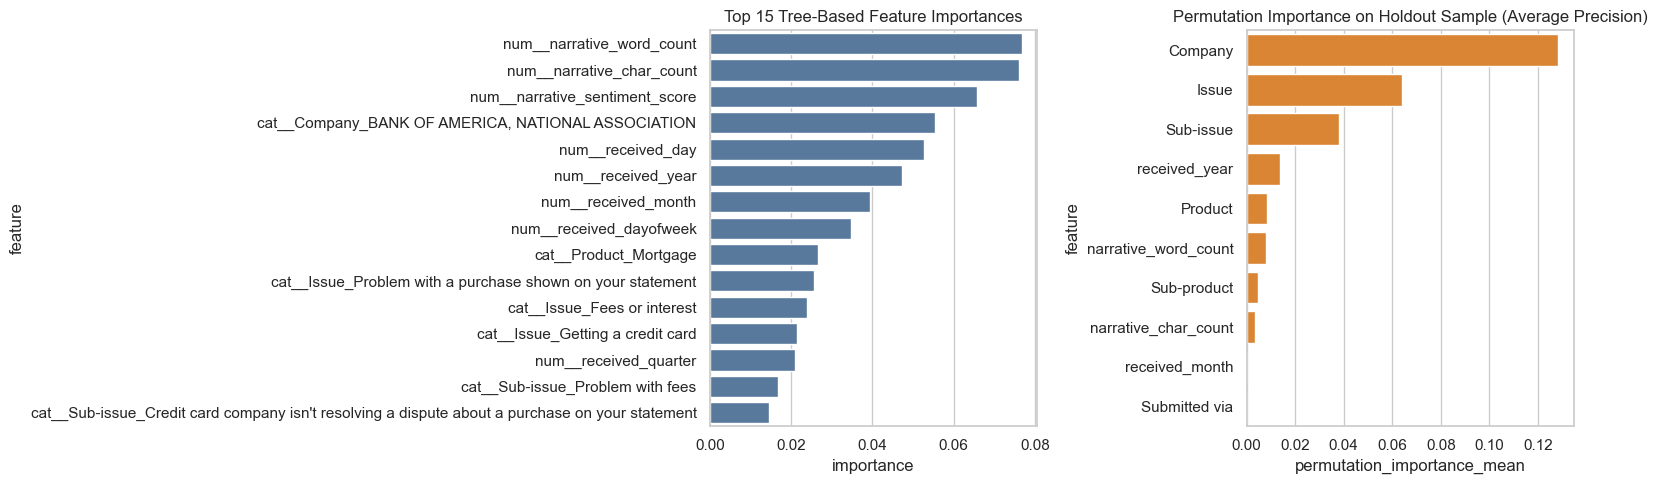

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 Tree-Based Feature Importances")

sns.barplot(data=perm_df.head(10), x="permutation_importance_mean", y="feature", ax=axes[1], color="#F58518")
axes[1].set_title("Permutation Importance on Holdout Sample (Average Precision)")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_feature_importance_plots_clean.png", dpi=200, bbox_inches="tight")


The feature importance results suggest that complaint specific information is more predictive of relief outcomes than geographic information (found in prior notebook analysis for relief in old notebooks folder). Issue type, company, and sub-issue consistently ranked among the most influential variables, indicating that the nature of the complaint and the institution involved are strong determinants of whether relief is ultimately provided.

When the values of Issue and Company were randomly shuffled as done in the Permutation Importance analysis, model performance decreased substantially, indicating that these variables contain information the model relies on for prediction. In contrast, shuffling variables such as received_day or Submitted via or even the narrative length features produced little change in performance, suggesting they contribute relatively little predictive signal. Given these results, we can see how much does the model suffer when a certain feature's information is destroyed? This is useful as it informs us how important Company and Issue really are whereas received_day isn't really generating much signal for us.


### Ablation Analysis

Ablation testing measures how much the model depends on different groups of features. To keep runtime reasonable, this section uses a 3-fold CV summary on the training set and compares F1 after removing one feature family at a time.


In [7]:
feature_groups = {
    "all_features": rf_features,
    "no_narrative_size": [f for f in rf_features if f not in {"narrative_char_count", "narrative_word_count"}],
    "no_sentiment": [f for f in rf_features if f != "narrative_sentiment_score"],
    "no_company": [f for f in rf_features if f != "Company"],
    "no_product_context": [f for f in rf_features if f not in {"Product", "Sub-product"}],
    "no_issue_context": [f for f in rf_features if f not in {"Issue", "Sub-issue"}],
}

ablation_rows = []
fast_cv = StratifiedKFold(n_splits=FAST_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for label, cols in feature_groups.items():
    ablation_pipeline, _, _ = build_rf_pipeline(selected_features=cols, **best_rf_params)
    scores = cross_validate(
        ablation_pipeline,
        train_df[cols],
        y_train,
        scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
        cv=fast_cv,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    ablation_rows.append(
        {
            "ablation": label,
            "cv_mean_f1": scores["test_f1"].mean(),
            "cv_mean_precision": scores["test_precision"].mean(),
            "cv_mean_recall": scores["test_recall"].mean(),
            "feature_count": len(cols),
        }
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("cv_mean_f1", ascending=False).reset_index(drop=True)
baseline_f1 = ablation_df.loc[ablation_df["ablation"].eq("all_features"), "cv_mean_f1"].iloc[0]
ablation_df["f1_drop_vs_all_features"] = baseline_f1 - ablation_df["cv_mean_f1"]
ablation_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_ablation_results_clean.csv", index=False)
display(ablation_df)


,ablation,cv_mean_f1,cv_mean_precision,cv_mean_recall,feature_count,f1_drop_vs_all_features
0,no_narrative_size,0.457002,0.363298,0.615905,13,-0.003813
1,all_features,0.453189,0.373920,0.575149,15,0.000000
2,no_sentiment,0.453108,0.366189,0.594168,14,0.000081
3,no_product_context,0.450843,0.370090,0.576740,13,0.002347
4,no_issue_context,0.363424,0.343481,0.385885,13,0.089766
5,no_company,0.328686,0.343272,0.315308,14,0.124503


We can see above that the ablation confirms the information we found in our permutation testing. Specifically, we can see that narrative and sentiment don't appear vital, but other features namely the Company and Issue related features are key in keeping our model's performance up.

### Sensitivity Analysis

Sensitivity analysis helps us understand whether the selected Random Forest is stable or fragile. Here we vary two influential hyperparameters, `max_depth` and `min_samples_leaf`, and track cross-validated F1. A stable model should not collapse from small changes around the selected setting.


,max_depth,min_samples_leaf,cv_mean_f1,cv_mean_precision,cv_mean_recall
6,None,2,0.453189,0.373920,0.575149
7,None,5,0.451339,0.339756,0.672101
3,22,2,0.447989,0.333102,0.683897
8,None,10,0.445057,0.323325,0.713850
4,22,5,0.442346,0.321792,0.707488
5,22,10,0.439027,0.315914,0.719549
0,14,2,0.435484,0.317580,0.693439
1,14,5,0.433644,0.314718,0.697548
2,14,10,0.431008,0.311732,0.699006


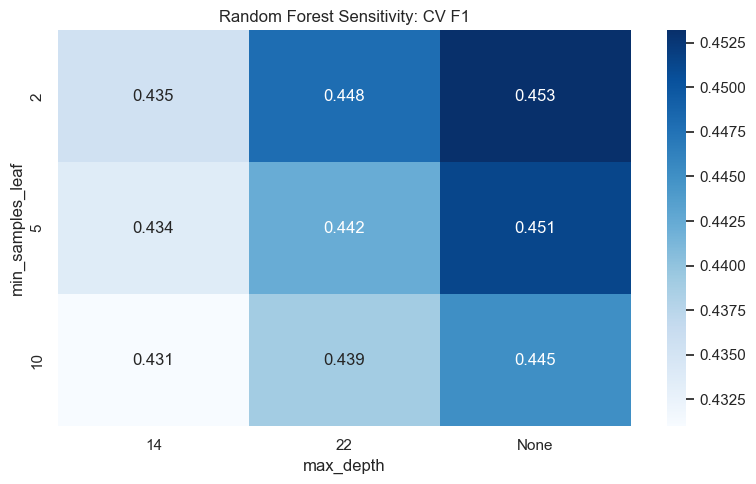

In [12]:
sensitivity_rows = []
sensitivity_train_df = train_df
sensitivity_y = sensitivity_train_df[target_col]
for max_depth in [14, 22, None]:
    for min_samples_leaf in [2, 5, 10]:
        pipeline, _, _ = build_rf_pipeline(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=best_rf_params["min_samples_split"],
            max_features=best_rf_params["max_features"],
        )
        scores = cross_validate(
            pipeline,
            sensitivity_train_df[rf_features],
            sensitivity_y,
            scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
            cv=fast_cv,
            n_jobs=N_JOBS,
            return_train_score=False,
        )
        sensitivity_rows.append(
            {
                "max_depth": str(max_depth),
                "min_samples_leaf": min_samples_leaf,
                "cv_mean_f1": scores["test_f1"].mean(),
                "cv_mean_precision": scores["test_precision"].mean(),
                "cv_mean_recall": scores["test_recall"].mean(),
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["cv_mean_f1", "cv_mean_recall"], ascending=False)
sensitivity_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_sensitivity_results_clean.csv", index=False)
display(sensitivity_df)

pivot_f1 = sensitivity_df.pivot(index="min_samples_leaf", columns="max_depth", values="cv_mean_f1")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="Blues")
plt.title("Random Forest Sensitivity: CV F1")
plt.ylabel("min_samples_leaf")
plt.xlabel("max_depth")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_sensitivity_heatmap_clean.png", dpi=200, bbox_inches="tight")


We can see above that the sensitivity testing confirms our choice in model hyperparameters. Additionally, we can see that although there is some tangible performance drops from choosing more min samples and/or less max_depth, the performance drop isn't extreme as the adjusted hyperparameters just result in a model that performs similarly to our other baseline models like logistic regression or SVM.

### Tradeoff Analysis

Tradeoff analysis asks how the Random Forest behaves when we change decision thresholds or training data size. This is still useful even with a more balanced target, because threshold shifts can change the precision-recall tradeoff materially.


,setting,accuracy,precision,recall,f1,balanced_accuracy,average_precision
0,default_0.50,0.781625,0.375043,0.583886,0.456722,0.701198,0.408751
1,best_f1_0.481,0.770917,0.364663,0.615955,0.458112,0.707889,0.408751


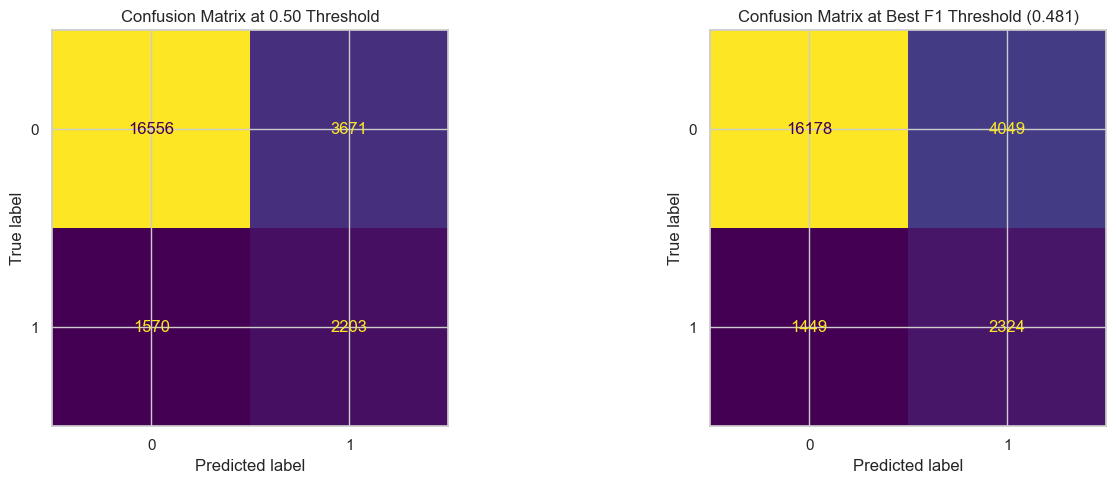

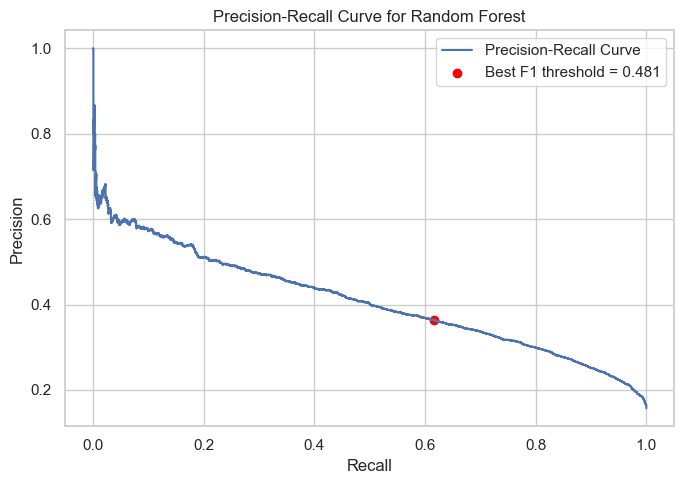

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
threshold_f1 = np.divide(
    2 * precisions[:-1] * recalls[:-1],
    precisions[:-1] + recalls[:-1],
    out=np.zeros_like(precisions[:-1]),
    where=(precisions[:-1] + recalls[:-1]) != 0,
)
best_threshold_idx = int(np.argmax(threshold_f1))
best_threshold = float(thresholds[best_threshold_idx])
threshold_pred = (test_proba >= best_threshold).astype(int)
threshold_metrics = score_predictions(y_test, threshold_pred, test_proba)

threshold_tradeoff_df = pd.DataFrame(
    {
        "setting": ["default_0.50", f"best_f1_{best_threshold:.3f}"],
        "accuracy": [holdout_metrics["accuracy"], threshold_metrics["accuracy"]],
        "precision": [holdout_metrics["precision"], threshold_metrics["precision"]],
        "recall": [holdout_metrics["recall"], threshold_metrics["recall"]],
        "f1": [holdout_metrics["f1"], threshold_metrics["f1"]],
        "balanced_accuracy": [holdout_metrics["balanced_accuracy"], threshold_metrics["balanced_accuracy"]],
        "average_precision": [holdout_metrics["average_precision"], threshold_metrics["average_precision"]],
    }
)
threshold_tradeoff_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_threshold_tradeoff_clean.csv", index=False)
display(threshold_tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix at 0.50 Threshold")
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix at Best F1 Threshold ({best_threshold:.3f})")
plt.tight_layout()
fig.savefig(VISUALS_DIR / "04_final_confusion_matrices_clean.png", dpi=200, bbox_inches="tight")

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx], color="red", label=f"Best F1 threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_precision_recall_curve_clean.png", dpi=200, bbox_inches="tight")


,train_size,train_f1_mean,validation_f1_mean
0,4000,0.752382,0.389524
1,8000,0.716057,0.410570
2,12000,0.694165,0.416935
3,16000,0.687888,0.423259
4,20000,0.689297,0.427287


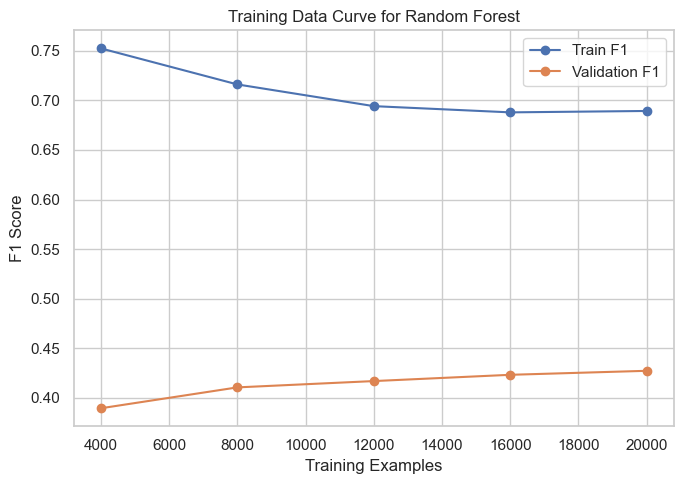

In [10]:
curve_train_df = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)
curve_y = curve_train_df[target_col]
curve_pipeline, _, _ = build_rf_pipeline(**best_rf_params)
train_sizes, train_scores, valid_scores = learning_curve(
    curve_pipeline,
    curve_train_df[rf_features],
    curve_y,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=fast_cv,
    scoring="f1",
    n_jobs=N_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_curve_df = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_f1_mean": train_scores.mean(axis=1),
        "validation_f1_mean": valid_scores.mean(axis=1),
    }
)
learning_curve_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_learning_curve_clean.csv", index=False)
display(learning_curve_df)

plt.figure(figsize=(7, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Train F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.title("Training Data Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_learning_curve_clean.png", dpi=200, bbox_inches="tight")


This section captures multiple project-required tradeoffs:

Because the model must ultimately produce a binary 0/1 prediction, the classification threshold matters. The default threshold of 0.50 is not necessarily the setting that gives the best balance between precision and recall. In our case, decreasing the threshold to roughly 0.48 produced a higher F1 score by roughly 0.002, suggesting a better overall balance between identifying positive cases and limiting incorrect positive predictions. More specifically, the higher threshold reduced false positives more than it reduced true positives, which is why F1 improved. The precision-recall curve also shows a clear tradeoff between these two metrics as the threshold changes.

The learning curve provides a second tradeoff perspective by comparing model performance as training size increases. Although the training F1 remains somewhat higher than the validation F1, both curves begin to flatten relatively quickly. This suggests that simply adding more of the same type of data may not lead to major improvements. Instead, the larger opportunity likely lies in improving feature quality or feature representation so the model can capture more useful signal. Given this performance, our goal is to try and improve our feature representation using Unsupervised methods on the consumer narrative portion of the data. Our hypothesis is that if we can identify latent topics, we might be able to improve performance for certain records.



### Failure Analysis

Failure analysis focuses on specific mistakes rather than aggregate metrics. To satisfy the assignment requirement, we select at least three concrete failed predictions and group them into different categories. The goal is not just to note the error, but to reason about why it likely occurred and what future improvements could address it.


In [11]:
failure_df = test_df[[
    "Complaint ID",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "Consumer complaint narrative",
    target_col,
]].copy()
failure_df["predicted_label"] = test_pred
failure_df["predicted_proba"] = test_proba
failure_df["error_type"] = np.where(
    (failure_df[target_col] == 1) & (failure_df["predicted_label"] == 0),
    "false_negative",
    np.where(
        (failure_df[target_col] == 0) & (failure_df["predicted_label"] == 1),
        "false_positive",
        "correct",
    ),
)
failure_df["narrative_present"] = failure_df["Consumer complaint narrative"].fillna("").str.len().gt(0)
failure_df["narrative_word_count"] = failure_df["Consumer complaint narrative"].fillna("").str.split().str.len().fillna(0)

false_negative_examples = failure_df.loc[failure_df["error_type"].eq("false_negative")].sort_values("predicted_proba", ascending=False)
false_positive_examples = failure_df.loc[failure_df["error_type"].eq("false_positive")].sort_values("predicted_proba", ascending=False)

failure_examples = pd.concat(
    [
        false_negative_examples.head(1).assign(failure_category="likely systematic minority-class miss"),
        false_positive_examples.head(1).assign(failure_category="aggressive positive flag / ambiguous case"),
        false_negative_examples.sort_values("narrative_word_count").head(1).assign(failure_category="sparse-information edge case"),
    ],
    axis=0,
).drop_duplicates(subset=["Complaint ID"]).reset_index(drop=True)

failure_examples.to_csv(OUTPUT_TABLES_DIR / "04_final_failure_examples_clean.csv", index=False)
display(failure_examples[[
    "Complaint ID",
    "failure_category",
    "error_type",
    target_col,
    "predicted_label",
    "predicted_proba",
    "Product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "narrative_present",
    "narrative_word_count",
]])


,Complaint ID,failure_category,error_type,target_relief,predicted_label,predicted_proba,Product,Issue,Sub-issue,Company,Submitted via,narrative_present,narrative_word_count
0,3107963,likely systematic minority-class miss,false_negative,1,0,0.499692,Checking or savings account,Problem with a lender or other company chargin...,Transaction was not authorized,M&T BANK CORPORATION,Web,True,125
1,7168942,aggressive positive flag / ambiguous case,false_positive,0,1,0.871965,Credit card or prepaid card,Fees or interest,Problem with fees,"BANK OF AMERICA, NATIONAL ASSOCIATION",Web,True,130
2,3978352,sparse-information edge case,false_negative,1,0,0.123152,Credit card or prepaid card,Incorrect information on your report,Account information incorrect,"CITIBANK, N.A.",Web,True,8
